# Excel dependency agent -- walkthrough

This notebook runs the whole baseline end to end: deterministic extraction,
graph visualization, an accuracy check against ground truth, the shared
query tools, and both agent modes.

```
Excel workbook
      |
      v
Deterministic extraction core   (core/)
   parse -> graph -> query tools
      |                    \
      v                     \  live queries
Deep agent                    ReAct agent
(full doc pass,                (per-question,
 offline)                       interactive)
      |                       /
      v                     /
Documentation store  <-----      (fast-path cache;
(agents/memory.py)                 never authoritative)
```

Sections 1-4 need no API key at all. Sections 5-6 call the Anthropic API
and need `ANTHROPIC_API_KEY` set in the environment -- they detect its
absence and print instructions instead of failing.


In [1]:
import os, sys, json
sys.path.insert(0, os.path.abspath("."))

from core.extractor import extract_workbook
from core.graph import build_column_graph, load_graph, to_edge_list, detect_stretched_columns
from core.tools import WorkbookContext

XLSX_PATH = "data/dependency_benchmark.xlsx"
GT_PATH = "data/ground_truth.json"


## 1. Deterministic extraction

`extract_workbook` tokenizes every formula in the workbook and resolves
every cell/range/named-range reference to a `(sheet, column)` pair -- this
step never touches an LLM. `build_column_graph` then collapses those
cell-level references into a column-level graph (the "400 identical rows
-> one node" step).


In [2]:
extraction = extract_workbook(XLSX_PATH)
graph = build_column_graph(extraction)

print(f"Sheets: {list(extraction.header_map.keys())}")
print(f"Column-level nodes: {graph.number_of_nodes()}")
print(f"Column-level edges: {graph.number_of_edges()}")
print(f"Cells flagged as using INDIRECT: {len(extraction.indirect_cells)}")


Sheets: ['Index', 'Products', 'Regions', 'Customers', 'Sales', 'Summary']
Column-level nodes: 26
Column-level edges: 38
Cells flagged as using INDIRECT: 1


### Stretched-pattern detection

Most of `Sales`' 400 rows share an identical formula template (only the row
number shifts). `detect_stretched_columns` checks this explicitly -- it's
what justifies collapsing 400 rows into a single graph node instead of 400.


In [3]:
stretched = detect_stretched_columns(XLSX_PATH, extraction)
for node, info in sorted(stretched.items()):
    if info["stretched"] and info["n_rows"] > 50:
        print(f"{node}: {info['n_rows']} rows, one template -> {info['sample']}")


Sales!F: 400 rows, one template -> =INDEX(Products!$E:$E,MATCH(C2,Products!$A:$A,0))
Sales!G: 400 rows, one template -> =INDEX(Products!$C:$C,MATCH(C2,Products!$A:$A,0))
Sales!H: 400 rows, one template -> =INDEX(Customers!$C:$C,MATCH(D2,Customers!$A:$A,0))
Sales!I: 400 rows, one template -> =INDEX(Regions!$C:$C,MATCH(H2,Regions!$A:$A,0))
Sales!J: 400 rows, one template -> =INDEX(Regions!$D:$D,MATCH(H2,Regions!$A:$A,0))
Sales!K: 400 rows, one template -> =INDEX(Regions!$E:$E,MATCH(H2,Regions!$A:$A,0))
Sales!L: 400 rows, one template -> =E2*F2
Sales!M: 400 rows, one template -> =IF(E2>=K2,L2*J2,0)
Sales!N: 400 rows, one template -> =(L2-M2)*I2
Sales!O: 400 rows, one template -> =L2-M2+N2


## 1b. Harder real-world constructs

`dependency_benchmark.xlsx` is clean by design. Real workbooks aren't --
they use Excel Tables, 3D ranges across sheets, broken external links, and
occasionally a genuine circular reference. `data/stress_test.xlsx`
exercises exactly those, and none of them require an LLM to handle
correctly -- they're all fully deterministic once the parser knows the
syntax. Three outcomes to look for below: the Table/3D-range edges resolve
correctly, the external link is flagged rather than silently dropped or
silently miscounted, and the circular reference is detected explicitly.


In [4]:
stress_ctx = WorkbookContext("data/stress_test.xlsx")

report_value = stress_ctx.resolve_column("Report", "Value")
print("Report!Value depends on:", stress_ctx.get_precedents(report_value))
print("  (BudgetTable[Q1]/[Q2] structured refs + a Jan:Mar 3D range, all resolved)")

print("\nCircular references found:", stress_ctx.find_cycles())
print("External-workbook references (flagged, not silently dropped):",
      stress_ctx.external_ref_warnings())
print("Unresolved references (should be empty here):", stress_ctx.unresolved_ref_warnings())
print("Benign LET-style local names filtered out:", stress_ctx.local_name_count())


Report!Value depends on: ['Budget!B', 'Budget!C', 'Feb!B', 'Jan!B', 'Mar!B']
  (BudgetTable[Q1]/[Q2] structured refs + a Jan:Mar 3D range, all resolved)

Circular references found: [['Cycles!B', 'Cycles!A']]
External-workbook references (flagged, not silently dropped): [('Report', 'B5', '[ArchivedActuals.xlsx]Sheet1!$B$2', 'ArchivedActuals.xlsx')]
Unresolved references (should be empty here): []
Benign LET-style local names filtered out: 2


## 2. Visualize the column-level graph

A quick static layout, colored by sheet, so the cross-sheet structure is
visible at a glance. (This is a debugging view, not the product -- a real
front-end would use Cytoscape.js/vis.js as discussed in the project README.)


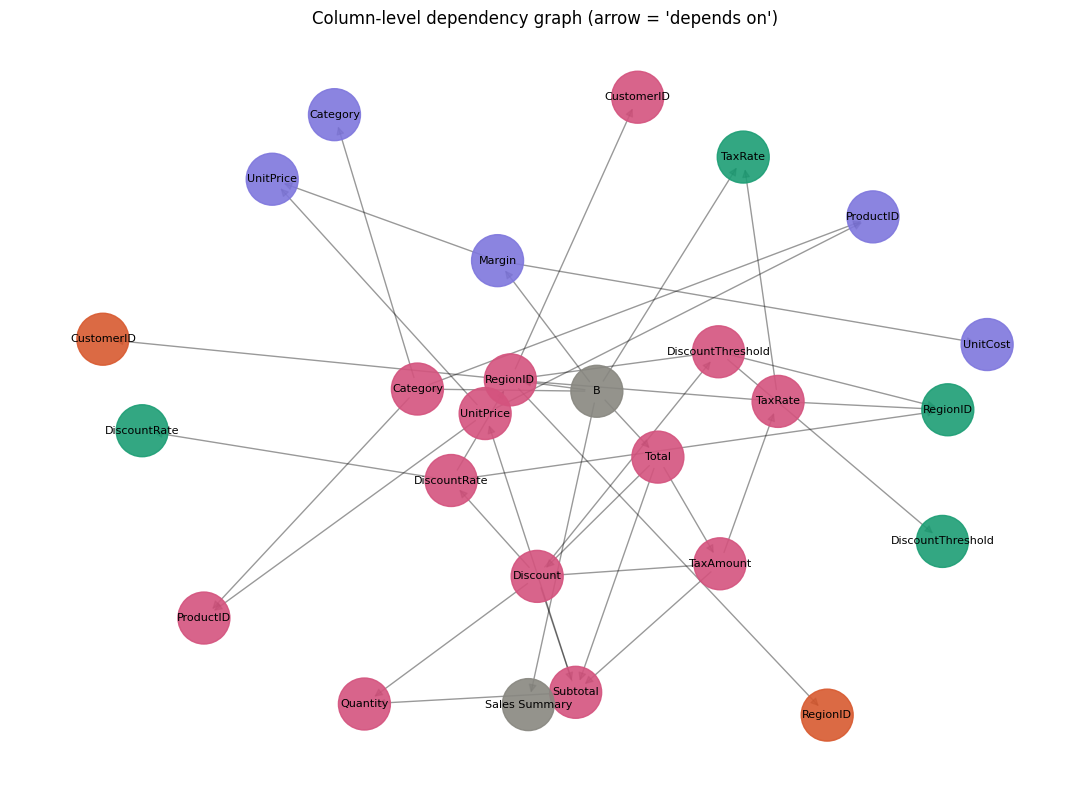

In [5]:
import matplotlib.pyplot as plt
import networkx as nx

sheet_colors = {"Products": "#7f77dd", "Regions": "#1d9e75", "Customers": "#d85a30",
                "Sales": "#d4537e", "Summary": "#888780"}
node_colors = [sheet_colors.get(graph.nodes[n]["sheet"], "#888") for n in graph.nodes]
labels = {n: graph.nodes[n]["header"] for n in graph.nodes}

plt.figure(figsize=(11, 8))
pos = nx.spring_layout(graph, k=0.9, seed=7)
nx.draw_networkx_nodes(graph, pos, node_color=node_colors, node_size=1400, alpha=0.9)
nx.draw_networkx_edges(graph, pos, arrows=True, arrowsize=12, alpha=0.4)
nx.draw_networkx_labels(graph, pos, labels=labels, font_size=8)
plt.title("Column-level dependency graph (arrow = 'depends on')")
plt.axis("off")
plt.tight_layout()
plt.show()


## 3. Validate extraction accuracy against ground truth

Same scoring logic as `validate.py`: set-overlap precision/recall/F1
against `data/ground_truth.json`, with the one INDIRECT edge and the
non-tabular `Summary` sheet reported separately rather than folded into
the headline score (see `core/README.md` for why).


In [6]:
with open(GT_PATH) as f:
    gt = json.load(f)

def edge_set(edges, exclude_kind=None, exclude_sheet=None):
    out = set()
    for e in edges:
        if e.get("kind") == exclude_kind:
            continue
        if exclude_sheet and (e["to"].startswith(exclude_sheet + "!") or
                               e["from"].startswith(exclude_sheet + "!")):
            continue
        out.add((e["to"], e["from"]))
    return out

predicted = to_edge_list(graph)
gt_scored = edge_set(gt["edges"], exclude_kind="indirect_unresolvable_statically", exclude_sheet="Summary")
pred_scored = edge_set(predicted, exclude_sheet="Summary")

tp = gt_scored & pred_scored
precision = len(tp) / len(pred_scored) if pred_scored else 0.0
recall = len(tp) / len(gt_scored) if gt_scored else 0.0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
print(f"Precision: {precision:.3f}  Recall: {recall:.3f}  F1: {f1:.3f}")
print(f"Missed: {sorted(gt_scored - pred_scored)}")
print(f"Spurious: {sorted(pred_scored - gt_scored)}")


Precision: 1.000  Recall: 1.000  F1: 1.000
Missed: []
Spurious: []


## 4. The shared query tools

Both agents call these same methods on `WorkbookContext` -- nothing more.
If an agent's answer can't be traced back to one of these calls, it's
guessing.


In [7]:
ctx = WorkbookContext(XLSX_PATH)

node = ctx.resolve_column("Sales", "TaxRate")
print("node:", node)
print("info:", ctx.get_column_info(node))
print("1-hop precedents:", ctx.get_precedents(node))
print("2-hop precedents:", ctx.get_precedents(node, max_depth=2))
print("dependents:", ctx.get_dependents(node))
print("path Total -> Regions.TaxRate:",
      ctx.find_path(ctx.resolve_column("Sales", "Total"), ctx.resolve_column("Regions", "TaxRate")))
print("INDIRECT warnings:", ctx.indirect_warnings())


node: Sales!I
info: {'sheet': 'Sales', 'column': 'I', 'header': 'TaxRate', 'stretched': True, 'sample': '=INDEX(Regions!$C:$C,MATCH(H2,Regions!$A:$A,0))', 'n_rows': 400}
1-hop precedents: ['Regions!A', 'Regions!C', 'Sales!H']
2-hop precedents: ['Customers!A', 'Customers!C', 'Regions!A', 'Regions!C', 'Sales!D', 'Sales!H']
dependents: ['Sales!N']
path Total -> Regions.TaxRate: ['Sales!O', 'Sales!N', 'Sales!I', 'Regions!C']
INDIRECT warnings: [('Summary', 'B27', '=COUNTA(INDIRECT("\'"&B26&"\'!A:A"))-1')]


## 5. Deep agent -- offline documentation pass

Runs one LLM call per column, with all the context (formula, precedents,
dependents) gathered deterministically beforehand. Needs
`ANTHROPIC_API_KEY`; skips gracefully if it isn't set.


In [8]:
if not os.environ.get("ANTHROPIC_API_KEY"):
    print("Set ANTHROPIC_API_KEY to run this cell -- see agents/README.md.")
else:
    from agents import DocStore, ProgressTracker, DeepDocumentationAgent

    doc_store = DocStore("data/doc_store.json")
    progress = ProgressTracker("data/progress.json")
    deep_agent = DeepDocumentationAgent(ctx, doc_store, progress)

    results = deep_agent.run(limit=3)   # small limit for a quick demo
    for node, explanation in results.items():
        print(f"--- {node} ---\n{explanation}\n")


Set ANTHROPIC_API_KEY to run this cell -- see agents/README.md.


## 6. ReAct agent -- interactive Q&A

A real think -> tool call -> observe loop. Checks the doc-store cache
first, falls back to live graph queries. Also needs `ANTHROPIC_API_KEY`.


In [9]:
if not os.environ.get("ANTHROPIC_API_KEY"):
    print("Set ANTHROPIC_API_KEY to run this cell -- see agents/README.md.")
else:
    from agents import DocStore, ReActAgent

    doc_store = DocStore("data/doc_store.json")
    react_agent = ReActAgent(ctx, doc_store)

    answer = react_agent.ask(
        "What does Sales.Total ultimately depend on, and is any part of "
        "that chain unresolvable statically?"
    )
    print(answer)


Set ANTHROPIC_API_KEY to run this cell -- see agents/README.md.


## Next steps

To point any of this at your own workbook instead of the benchmark files,
run `python inspect_workbook.py path/to/your_file.xlsx` first -- it prints
node/edge counts plus all three warning lists (INDIRECT, external refs,
unresolved refs) so you can see exactly what did and didn't resolve before
trusting the graph.

See the "What's included / what's a deliberate stub" section of the
top-level README for the remaining follow-up work -- row-level granularity
for report-style sheets, re-parsing on file change, and a real
visualization front-end are the biggest open pieces.
